# Geneva Wind-Speed Climatology

This notebook computes daily wind-speed climatology from all available LéXPLORE meteorological station CSV files and overlays the available 2026 daily means.

The source mapping is explicit: `y3` is wind speed in m/s. `y14` is only the wind-speed quality flag, where `0` means the observation passed quality control.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from netCDF4 import Dataset, num2date

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data" / "léxploremeteostation_datalakesdownload (2)"
RESULTS_DIR = PROJECT_DIR / "results"
GRAPHS_DIR = PROJECT_DIR / "graphs"
OUTPUT_CSV = RESULTS_DIR / "geneva_wind_climatology_netcdf.csv"
OUTPUT_DAILY_CSV = RESULTS_DIR / "geneva_daily_wind_netcdf.csv"
OUTPUT_PNG = GRAPHS_DIR / "geneva_wind_climatology_netcdf.png"
OUTPUT_MAX_PNG = GRAPHS_DIR / "geneva_wind_maximum_climatology_netcdf.png"
assert DATA_DIR.is_dir(), f"Missing NetCDF directory: {DATA_DIR}"
RESULTS_DIR.mkdir(exist_ok=True)
GRAPHS_DIR.mkdir(exist_ok=True)

# The NetCDF files have named variables. Legacy y4 is WindDir, not wind speed.
# Wind speed is WS; WS_qual is its quality flag.

## 2. Load Dataset and Inspect Columns

Load the NetCDF files directly. Each file contains named time-series variables; we construct an explicit 19-column meteorological DataFrame from the documented fields and do not flatten extra NetCDF variables such as `WindGust` into the analysis frame.

In [2]:
# The documented 19 columns are time plus the seven measurements and eleven QC fields.
METEO_COLUMNS = [
    "time", "AirTC", "RH", "Slrw", "WS", "WindDir", "Rain", "BP",
    "time_qual", "Batt_qual", "Ptemp_qual", "AirTC_qual", "RH_qual",
    "Slrw_qual", "Slrm_qual", "WS_qual", "WindDir_qual", "Rain_qual", "BP_qual",
]

nc_paths = sorted(DATA_DIR.glob("*.nc"))
assert nc_paths, f"No NetCDF files found in {DATA_DIR}"

frames = []
for path in nc_paths:
    with Dataset(path) as source:
        missing = [name for name in METEO_COLUMNS if name not in source.variables]
        assert not missing, f"{path.name} is missing {missing}"
        values = {}
        time_var = source.variables["time"]
        values["time"] = num2date(time_var[:], time_var.units, only_use_cftime_datetimes=False)
        for name in METEO_COLUMNS[1:]:
            values[name] = source.variables[name][:]
        frames.append(pd.DataFrame(values))

raw = pd.concat(frames, ignore_index=True)
raw["time"] = pd.to_datetime(raw["time"], utc=True)
print("NetCDF files:", len(nc_paths))
print("DataFrame shape:", raw.shape)
print("Column count:", len(raw.columns))
print("Columns:", raw.columns.tolist())
assert len(raw.columns) == 19
raw.head()

NetCDF files: 371
DataFrame shape: (364157, 19)
Column count: 19
Columns: ['time', 'AirTC', 'RH', 'Slrw', 'WS', 'WindDir', 'Rain', 'BP', 'time_qual', 'Batt_qual', 'Ptemp_qual', 'AirTC_qual', 'RH_qual', 'Slrw_qual', 'Slrm_qual', 'WS_qual', 'WindDir_qual', 'Rain_qual', 'BP_qual']


,time,AirTC,RH,Slrw,WS,WindDir,Rain,BP,time_qual,Batt_qual,Ptemp_qual,AirTC_qual,RH_qual,Slrw_qual,Slrm_qual,WS_qual,WindDir_qual,Rain_qual,BP_qual
0,2019-07-29 18:00:00+00:00,23.39,60.12,61.07,2.201,239.5,0.0,968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-07-29 18:10:00+00:00,23.31,60.19,62.85,1.765,236.6,0.0,968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-07-29 18:20:00+00:00,23.43,58.28,113.00,1.286,264.0,0.0,968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-07-29 18:30:00+00:00,23.63,57.70,95.00,0.738,25.3,0.0,968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-07-29 18:40:00+00:00,23.74,58.62,69.17,0.369,275.5,0.0,969.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Validate Target Columns (`WS` and `WS_qual`)

In the NetCDF schema, `WS` is wind speed in m/s and `WS_qual` is its quality flag. The legacy `y4` position corresponds to `WindDir`, so it must not be used as wind speed.

In [3]:
print(raw[["WS", "WS_qual", "WindDir"]].dtypes)
print(raw[["WS", "WS_qual", "WindDir"]].isna().sum())
print(raw[["WS", "WS_qual", "WindDir"]].describe())
assert raw["WS"].notna().any()
assert (raw["WS"].dropna() >= 0).all()
assert set(pd.Series(raw["WS_qual"]).dropna().unique()).issubset({0, 1})
assert float(raw["WS"].median()) < float(raw["WindDir"].median())

WS         float64
WS_qual    float64
WindDir    float64
dtype: object
WS         0
WS_qual    0
WindDir    0
dtype: int64
                  WS        WS_qual        WindDir
count  364157.000000  364157.000000  364157.000000
mean        2.568857       0.001354     164.382564
std         2.187034       0.036769     114.688916
min         0.000000       0.000000       0.000000
25%         1.148000       0.000000      47.390000
50%         1.813000       0.000000     158.600000
75%         3.257000       0.000000     263.300000
max        17.520000       1.000000     360.000000


## 4. Assign Wind Speed to the Correct NetCDF Variable

The canonical feature mapping uses `WS` for wind speed and `WS_qual` for quality control. For the legacy axis nomenclature, `y3` is wind speed and `y4` is wind direction; neither generic axis label is used to infer the NetCDF value.

In [4]:
FEATURE_COLUMNS = {
    "wind_speed": "WS",
    "wind_speed_quality_flag": "WS_qual",
    "legacy_y3": "WS",
    "legacy_y4": "WindDir",
}
assert FEATURE_COLUMNS["wind_speed"] == "WS"
assert FEATURE_COLUMNS["wind_speed_quality_flag"] == "WS_qual"
assert FEATURE_COLUMNS["legacy_y4"] == "WindDir"

observations = raw[(raw["WS_qual"] == 0) & raw["WS"].notna() & (raw["WS"] >= 0)].copy()
observations = observations.rename(columns={"time": "timestamp", "WS": "wind_speed_m_s"})
observations = observations.drop_duplicates(subset="timestamp").sort_values("timestamp")
observations[["timestamp", "wind_speed_m_s"]].head()

,timestamp,wind_speed_m_s
0,2019-07-29 18:00:00+00:00,2.201
1,2019-07-29 18:10:00+00:00,1.765
2,2019-07-29 18:20:00+00:00,1.286
3,2019-07-29 18:30:00+00:00,0.738
4,2019-07-29 18:40:00+00:00,0.369


## 5. Calculate Daily Mean and Maximum Wind Speed

Daily values are calculated from quality-approved `WS` observations. The climatology is grouped by day of year, and the complete daily table is retained for threshold-day reporting.

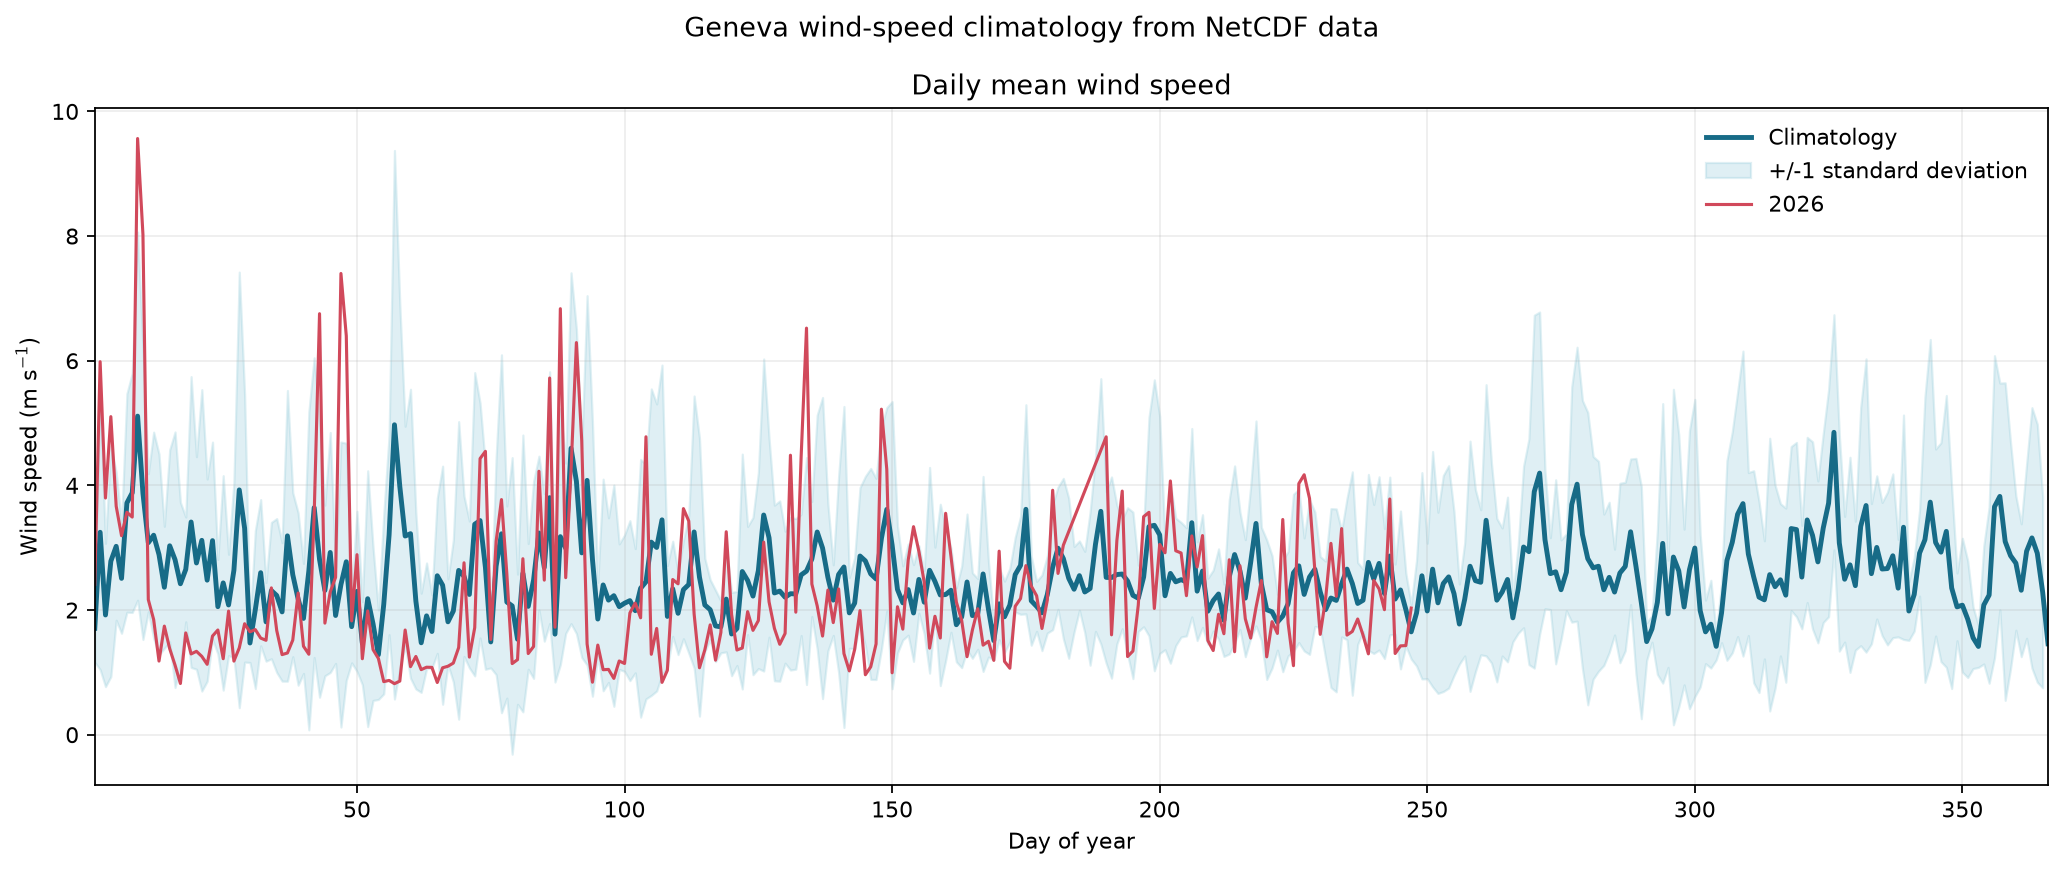

In [5]:
daily = (observations.set_index("timestamp")["wind_speed_m_s"].resample("D").agg(daily_mean="mean", daily_max="max", observations="count").dropna(subset=["daily_mean"]).reset_index())
daily["year"] = daily["timestamp"].dt.year
daily["day_of_year"] = daily["timestamp"].dt.dayofyear

climatology = daily.groupby("day_of_year")[["daily_mean"]].agg(["mean", "std"]).reset_index()
climatology.columns = ["day_of_year", "mean_wind_speed", "std_wind_speed"]
year_2026 = daily[daily["year"] == 2026]

for mean_col, std_col, year_col, title, output_path in [
    ("mean_wind_speed", "std_wind_speed", "daily_mean", "Daily mean wind speed", OUTPUT_PNG),
]:
    figure, axis = plt.subplots(figsize=(13, 5.5), dpi=160)
    axis.plot(climatology["day_of_year"], climatology[mean_col], color="#176b87", linewidth=2.2, label="Climatology")
    axis.fill_between(climatology["day_of_year"], climatology[mean_col] - climatology[std_col], climatology[mean_col] + climatology[std_col], color="#8ec9d8", alpha=0.28, label="+/-1 standard deviation")
    axis.plot(year_2026["day_of_year"], year_2026[year_col], color="#d1495b", linewidth=1.4, label="2026")
    axis.set_xlabel("Day of year")
    axis.set_ylabel("Wind speed (m s$^{-1}$)")
    axis.set_title(title)
    axis.set_xlim(1, 366)
    axis.grid(True, alpha=0.22)
    axis.legend(frameon=False)
    figure.suptitle("Geneva wind-speed climatology from NetCDF data")
    figure.tight_layout()
    figure.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(figure)

## 6. Threshold Days and Save Outputs

Report every calendar day whose daily maximum wind speed exceeds 4 m/s. The date list is exported together with the daily table and climatology.

In [6]:
assert len(raw.columns) == 19
assert FEATURE_COLUMNS["wind_speed"] == "WS"
assert FEATURE_COLUMNS["wind_speed_quality_flag"] == "WS_qual"
assert FEATURE_COLUMNS["legacy_y4"] == "WindDir"
assert "WindDir" not in [FEATURE_COLUMNS["wind_speed"]]
assert "daily_mean" in daily.columns and "daily_max" in daily.columns

threshold_days = daily.loc[daily["daily_max"] > 4, ["timestamp", "daily_max"]].copy()
threshold_days["date"] = threshold_days["timestamp"].dt.date
threshold_days = threshold_days[["date", "daily_max"]].sort_values("date")

climatology.to_csv(OUTPUT_CSV, index=False)
daily.to_csv(OUTPUT_DAILY_CSV, index=False)
threshold_days.to_csv(Path.cwd() / "geneva_days_daily_max_wind_over_4ms.csv", index=False)

print(f"NetCDF files: {len(nc_paths):,}")
print(f"Imported DataFrame columns: {len(raw.columns)}")
print(f"Raw observations: {len(raw):,}")
print(f"Quality-approved observations: {len(observations):,}")
print(f"Daily means: {len(daily):,}")
print(f"Years: {daily['year'].min()}-{daily['year'].max()}")
print(f"2026 daily records: {len(year_2026):,}")
print(f"Days with daily maximum wind speed > 4 m/s: {len(threshold_days):,}")
threshold_days

NetCDF files: 371
Imported DataFrame columns: 19
Raw observations: 364,157
Quality-approved observations: 363,660
Daily means: 2,539
Years: 2019-2026
2026 daily records: 240
Days with daily maximum wind speed > 4 m/s: 1,886


,date,daily_max
1,2019-07-30,7.176
2,2019-07-31,6.217
3,2019-08-01,4.274
4,2019-08-02,4.425
5,2019-08-03,7.456
...,...,...
2531,2026-08-28,8.080
2532,2026-08-29,5.435
2533,2026-08-30,7.005
2534,2026-08-31,7.278


## 7. Density of Daily Mean Wind Speed

Compare the distribution of daily mean wind speeds from the baseline period 2019-2025 with the available daily means from 2026. The curves are normalized probability densities, so their areas are approximately one.

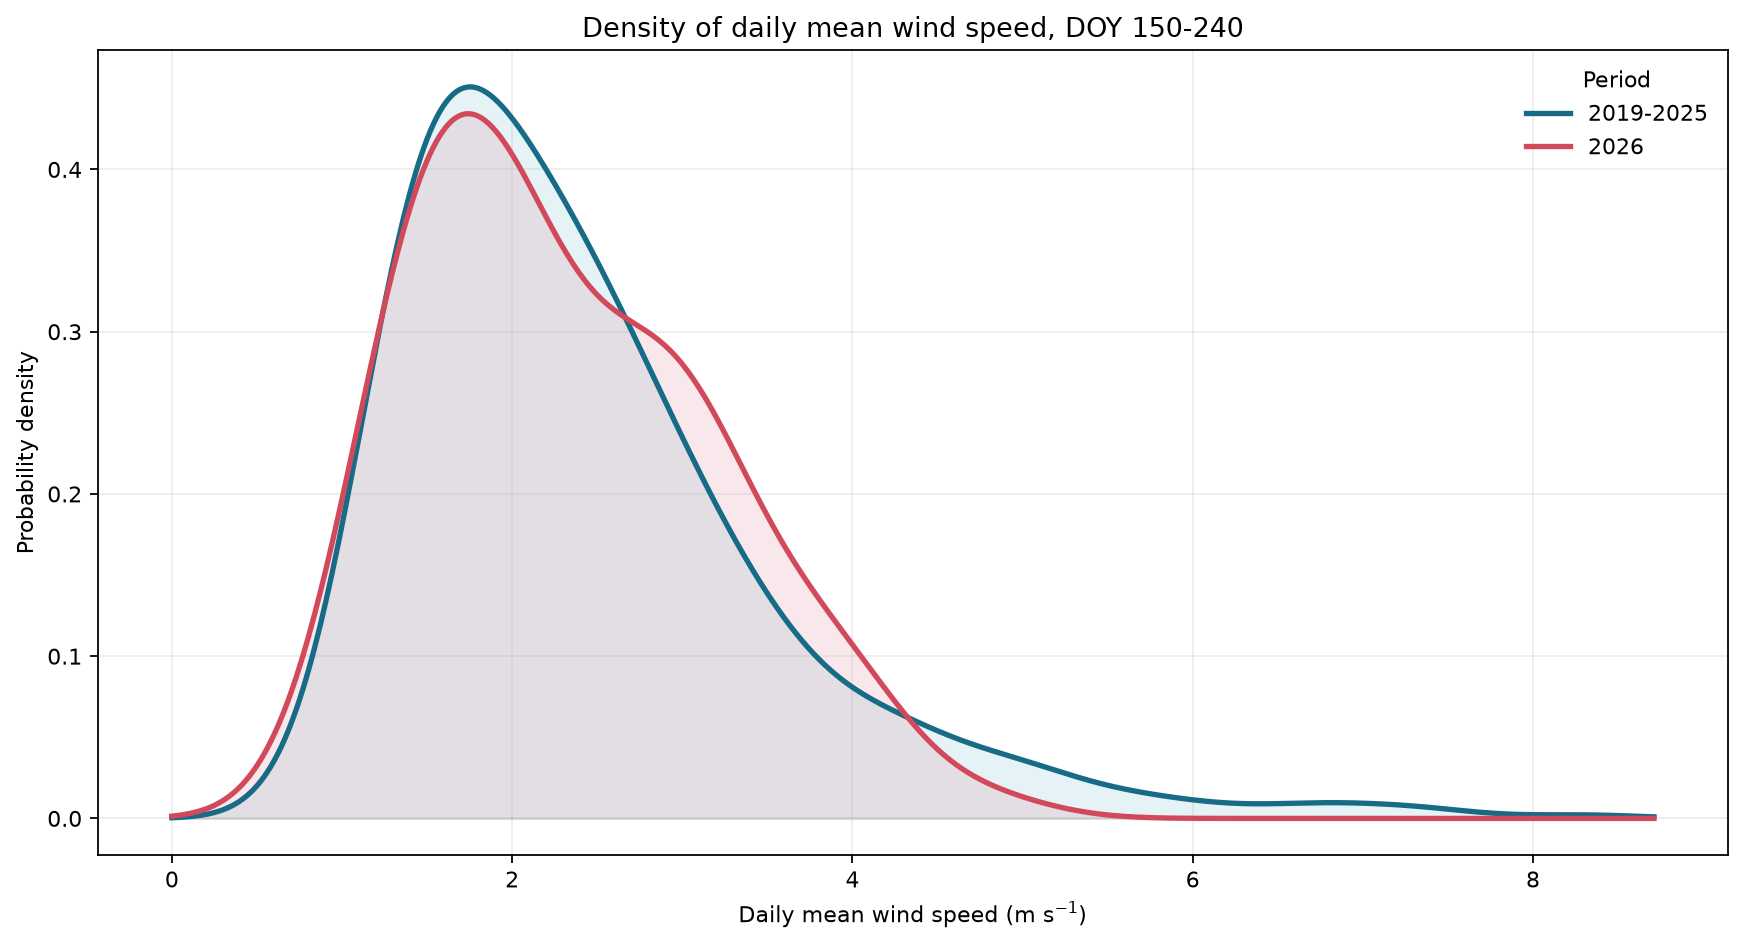

DOY window: 150-240
2019-2025 daily means: 568
2026 daily means: 84
Saved: geneva_daily_mean_wind_density_doy150_240_2019_2026.png


In [7]:
# Restrict both periods to the requested day-of-year window.
DOY_START, DOY_END = 150, 240
seasonal_daily = daily[daily["day_of_year"].between(DOY_START, DOY_END)]
baseline_daily_mean = seasonal_daily.loc[seasonal_daily["year"].between(2019, 2025), "daily_mean"].dropna().to_numpy()
wind_2026_daily_mean = seasonal_daily.loc[seasonal_daily["year"] == 2026, "daily_mean"].dropna().to_numpy()
assert len(baseline_daily_mean) > 1
assert len(wind_2026_daily_mean) > 1

# Evaluate a Gaussian kernel density estimate using NumPy only.
def gaussian_density(values, grid):
    bandwidth = 1.06 * values.std(ddof=1) * len(values) ** (-1 / 5)
    bandwidth = max(bandwidth, 1e-3)
    kernels = np.exp(-0.5 * ((grid[:, None] - values[None, :]) / bandwidth) ** 2)
    return kernels.mean(axis=1) / (bandwidth * np.sqrt(2 * np.pi))

all_values = np.concatenate([baseline_daily_mean, wind_2026_daily_mean])
wind_grid = np.linspace(0, max(6, all_values.max() * 1.05), 500)
baseline_density = gaussian_density(baseline_daily_mean, wind_grid)
density_2026 = gaussian_density(wind_2026_daily_mean, wind_grid)

figure, axis = plt.subplots(figsize=(11, 6), dpi=160)
axis.plot(wind_grid, baseline_density, color="#176b87", linewidth=2.4, label="2019-2025")
axis.fill_between(wind_grid, baseline_density, color="#8ec9d8", alpha=0.22)
axis.plot(wind_grid, density_2026, color="#d1495b", linewidth=2.4, label="2026")
axis.fill_between(wind_grid, density_2026, color="#d1495b", alpha=0.12)
axis.set_title(f"Density of daily mean wind speed, DOY {DOY_START}-{DOY_END}")
axis.set_xlabel("Daily mean wind speed (m s$^{-1}$)")
axis.set_ylabel("Probability density")
axis.grid(True, alpha=0.22)
axis.legend(frameon=False, title="Period")
figure.tight_layout()
DENSITY_PNG = Path.cwd() / "geneva_daily_mean_wind_density_doy150_240_2019_2026.png"
figure.savefig(DENSITY_PNG, bbox_inches="tight")
plt.show()

print(f"DOY window: {DOY_START}-{DOY_END}")
print(f"2019-2025 daily means: {len(baseline_daily_mean):,}")
print(f"2026 daily means: {len(wind_2026_daily_mean):,}")
print(f"Saved: {DENSITY_PNG.name}")

## 8. Density of Daily Maximum Wind Speed

Compare daily maximum wind-speed distributions for 2019-2025 and 2026 over the same requested day-of-year window, 150-240.

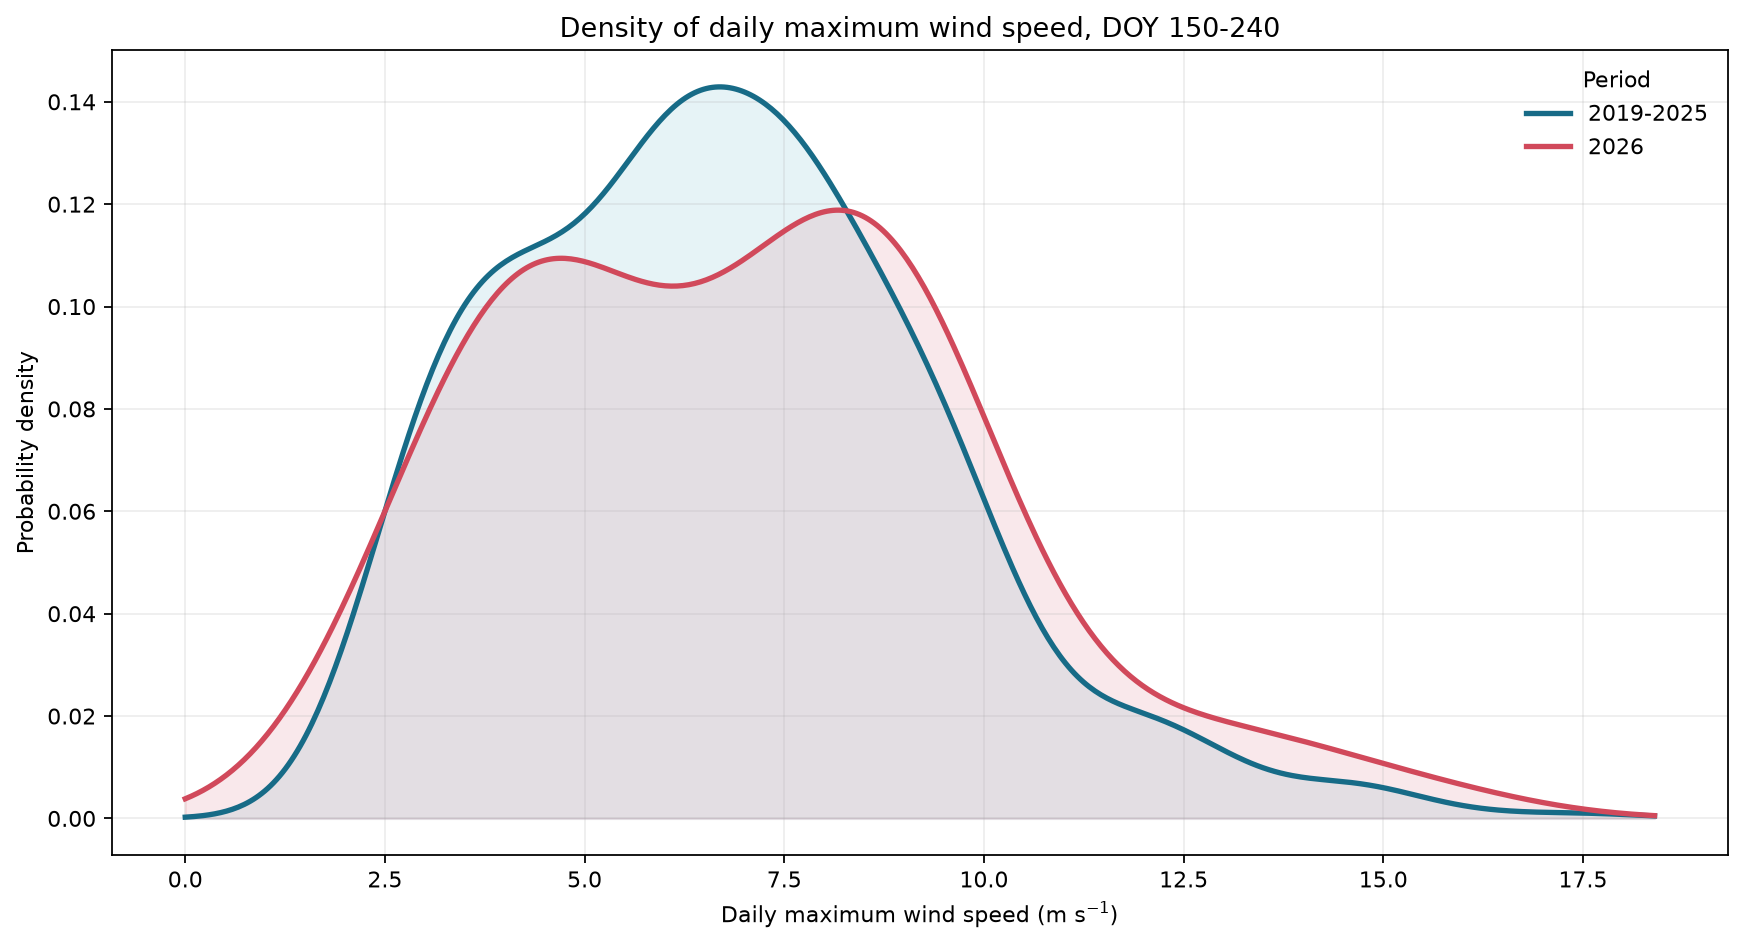

DOY window: 150-240
2019-2025 daily maxima: 568
2026 daily maxima: 84
Saved: geneva_daily_max_wind_density_doy150_240_2019_2026.png


In [8]:
# Select daily maximum wind speeds for the same DOY window and periods.
baseline_daily_max = seasonal_daily.loc[seasonal_daily["year"].between(2019, 2025), "daily_max"].dropna().to_numpy()
wind_2026_daily_max = seasonal_daily.loc[seasonal_daily["year"] == 2026, "daily_max"].dropna().to_numpy()
assert len(baseline_daily_max) > 1
assert len(wind_2026_daily_max) > 1

# Use the same Gaussian KDE function defined in the previous density section.
all_max_values = np.concatenate([baseline_daily_max, wind_2026_daily_max])
max_wind_grid = np.linspace(0, max(8, all_max_values.max() * 1.05), 500)
baseline_max_density = gaussian_density(baseline_daily_max, max_wind_grid)
density_2026_max = gaussian_density(wind_2026_daily_max, max_wind_grid)

figure, axis = plt.subplots(figsize=(11, 6), dpi=160)
axis.plot(max_wind_grid, baseline_max_density, color="#176b87", linewidth=2.4, label="2019-2025")
axis.fill_between(max_wind_grid, baseline_max_density, color="#8ec9d8", alpha=0.22)
axis.plot(max_wind_grid, density_2026_max, color="#d1495b", linewidth=2.4, label="2026")
axis.fill_between(max_wind_grid, density_2026_max, color="#d1495b", alpha=0.12)
axis.set_title(f"Density of daily maximum wind speed, DOY {DOY_START}-{DOY_END}")
axis.set_xlabel("Daily maximum wind speed (m s$^{-1}$)")
axis.set_ylabel("Probability density")
axis.grid(True, alpha=0.22)
axis.legend(frameon=False, title="Period")
figure.tight_layout()
MAX_DENSITY_PNG = Path.cwd() / "geneva_daily_max_wind_density_doy150_240_2019_2026.png"
figure.savefig(MAX_DENSITY_PNG, bbox_inches="tight")
plt.show()

print(f"DOY window: {DOY_START}-{DOY_END}")
print(f"2019-2025 daily maxima: {len(baseline_daily_max):,}")
print(f"2026 daily maxima: {len(wind_2026_daily_max):,}")
print(f"Saved: {MAX_DENSITY_PNG.name}")

## 10. Annual Violin Plots for Daily Wind Speed

Compare the distribution of daily mean wind speed by year for the requested DOY window, 150-240. Each violin shows the distribution shape; the red line marks its median.

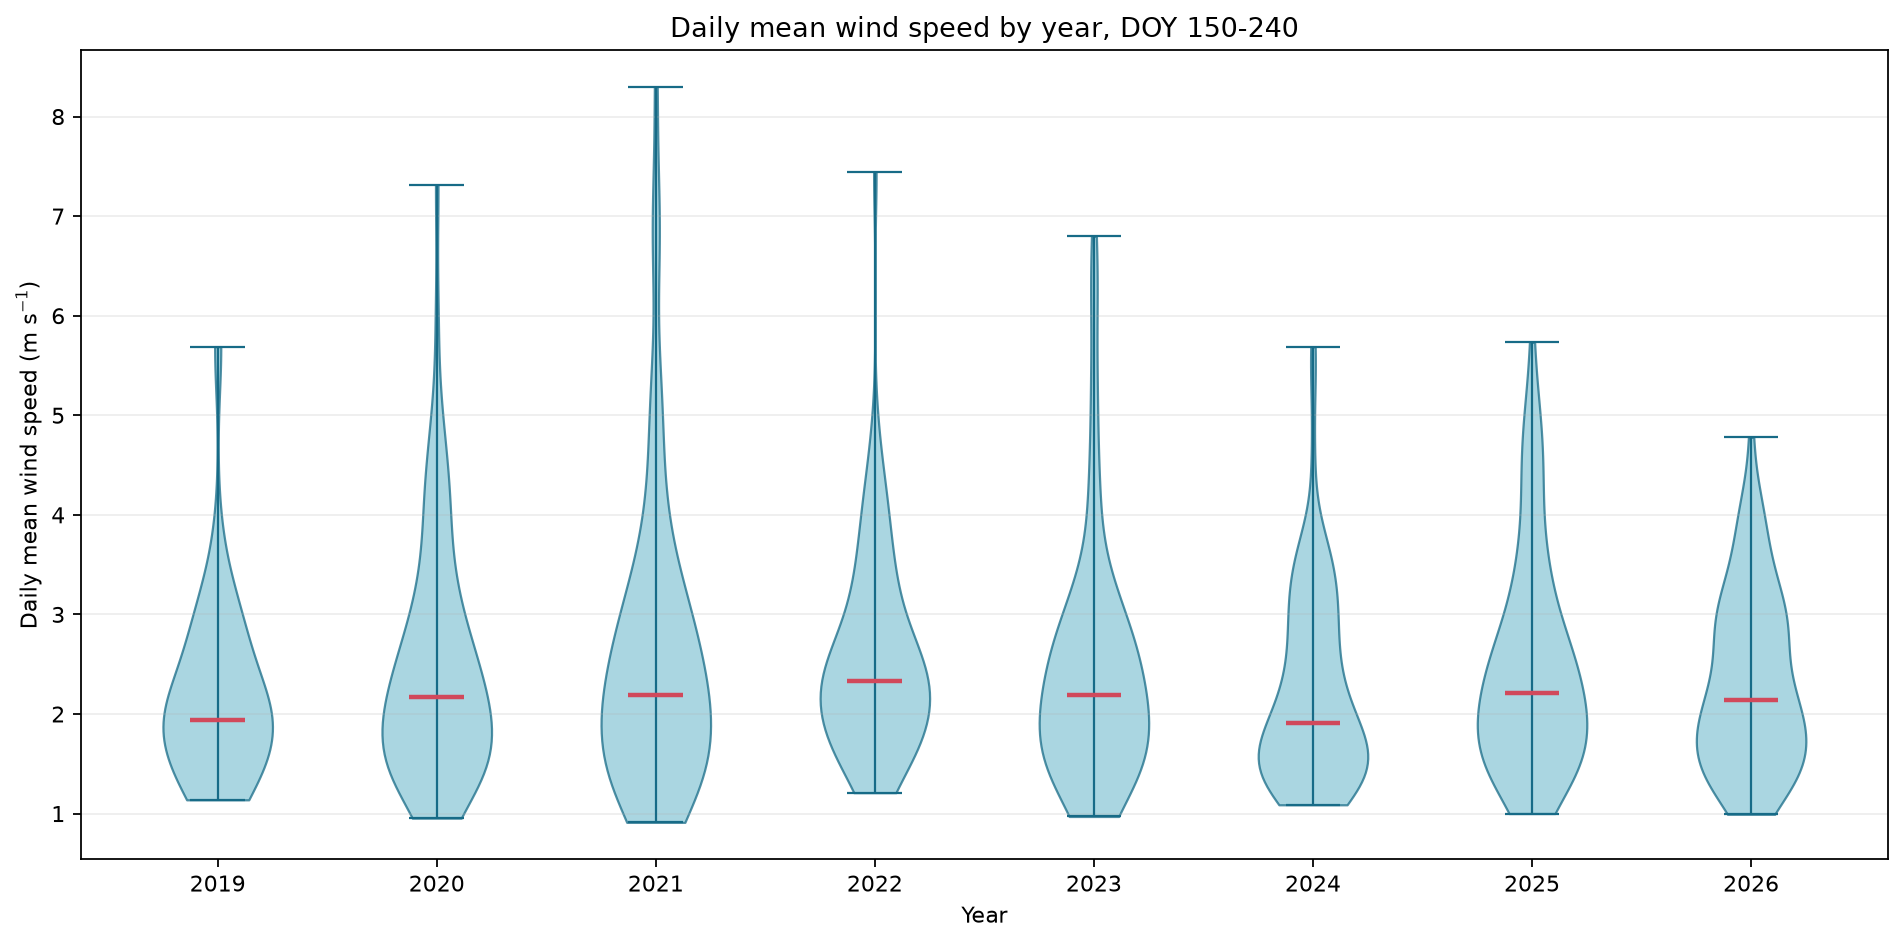

Years plotted: [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Total daily values plotted: 652
Saved: geneva_daily_mean_wind_violin_by_year_doy150_240.png


In [9]:
# Use daily mean wind speed for each year within DOY 150-240.
violin_data = seasonal_daily[["year", "daily_mean"]].dropna().copy()
violin_years = sorted(violin_data["year"].unique())
violin_values = [violin_data.loc[violin_data["year"] == year, "daily_mean"] for year in violin_years]
assert violin_years

figure, axis = plt.subplots(figsize=(12, 6), dpi=160)
parts = axis.violinplot(violin_values, positions=np.arange(1, len(violin_years) + 1), showmeans=False, showmedians=True, showextrema=True)
for body in parts["bodies"]:
    body.set_facecolor("#8ec9d8")
    body.set_edgecolor("#176b87")
    body.set_alpha(0.75)
for key in ("cmedians", "cmins", "cmaxes", "cbars"):
    parts[key].set_color("#d1495b" if key == "cmedians" else "#176b87")
    parts[key].set_linewidth(2 if key == "cmedians" else 1)
axis.set_xticks(np.arange(1, len(violin_years) + 1), labels=violin_years)
axis.set_title(f"Daily mean wind speed by year, DOY {DOY_START}-{DOY_END}")
axis.set_xlabel("Year")
axis.set_ylabel("Daily mean wind speed (m s$^{-1}$)")
axis.grid(True, axis="y", alpha=0.22)
figure.tight_layout()
VIOLIN_PNG = Path.cwd() / "geneva_daily_mean_wind_violin_by_year_doy150_240.png"
figure.savefig(VIOLIN_PNG, bbox_inches="tight")
plt.show()

print(f"Years plotted: {violin_years}")
print(f"Total daily values plotted: {len(violin_data):,}")
print(f"Saved: {VIOLIN_PNG.name}")

## 9. Top 40 Windiest Days

Rank the 40 calendar days with the highest daily mean wind speed and the 40 calendar days with the highest daily maximum wind speed across all available years.

In [10]:
# Keep the date and coverage fields with each ranking.
ranking_columns = ["timestamp", "year", "day_of_year", "daily_mean", "daily_max", "observations"]

# Top 40 days ranked by daily mean wind speed.
top_40_mean = (
    daily[ranking_columns]
    .sort_values(["daily_mean", "daily_max"], ascending=False)
    .head(40)
    .reset_index(drop=True)
)
top_40_mean.index = top_40_mean.index + 1
top_40_mean.index.name = "rank"

# Top 40 days ranked by daily maximum wind speed.
top_40_max = (
    daily[ranking_columns]
    .sort_values(["daily_max", "daily_mean"], ascending=False)
    .head(40)
    .reset_index(drop=True)
)
top_40_max.index = top_40_max.index + 1
top_40_max.index.name = "rank"

print("Top 40 days by daily mean wind speed")
display(top_40_mean)
print("Top 40 days by daily maximum wind speed")
display(top_40_max)

Top 40 days by daily mean wind speed


,timestamp,year,day_of_year,daily_mean,daily_max,observations
rank,,,,,,
1,2023-02-26 00:00:00+00:00,2023,57,11.483965,14.78,144
2,2020-01-28 00:00:00+00:00,2020,28,9.970979,15.54,144
3,2026-01-09 00:00:00+00:00,2026,9,9.564750,15.17,144
4,2020-02-26 00:00:00+00:00,2020,57,9.515750,14.04,144
5,2022-09-27 00:00:00+00:00,2022,270,9.364882,12.51,144
6,2020-03-30 00:00:00+00:00,2020,90,9.178146,11.44,144
7,2025-10-23 00:00:00+00:00,2025,296,8.777153,15.53,144
8,2025-12-24 00:00:00+00:00,2025,358,8.590840,12.42,144
9,2022-03-18 00:00:00+00:00,2022,77,8.524542,10.72,144


Top 40 days by daily maximum wind speed


,timestamp,year,day_of_year,daily_mean,daily_max,observations
rank,,,,,,
1,2023-06-22 00:00:00+00:00,2023,173,2.922119,17.52,143
2,2024-05-20 00:00:00+00:00,2024,141,1.793035,16.91,144
3,2020-10-04 00:00:00+00:00,2020,278,6.695201,16.59,144
4,2022-01-09 00:00:00+00:00,2022,9,5.830201,16.36,144
5,2019-12-14 00:00:00+00:00,2019,348,5.966556,16.15,144
6,2020-08-12 00:00:00+00:00,2020,225,4.984597,15.99,144
7,2026-07-17 00:00:00+00:00,2026,198,3.568146,15.83,144
8,2020-02-10 00:00:00+00:00,2020,41,8.253944,15.77,144
9,2024-11-21 00:00:00+00:00,2024,326,5.334343,15.77,143


## 11. Dotplots of the 40 Windiest Days

Plot the top 40 days ranked by daily mean and daily maximum wind speed. Rank is on the x-axis, wind speed on the y-axis, 2026 is red, and other years are grey.

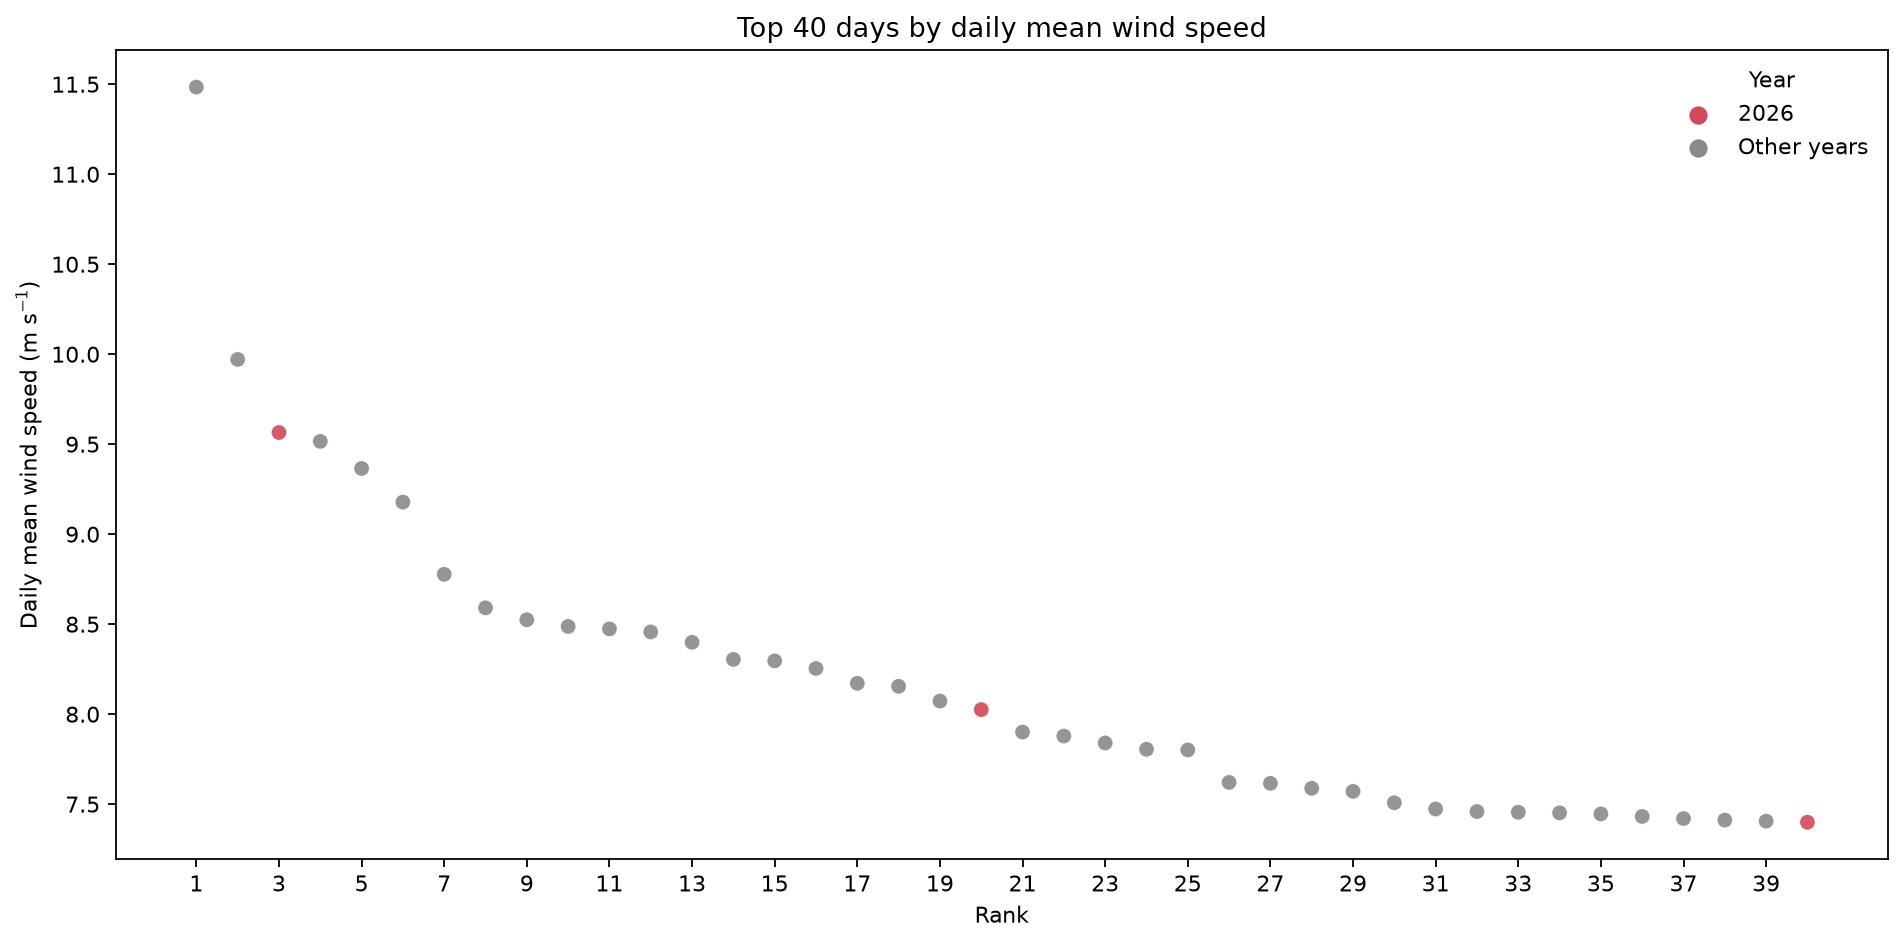

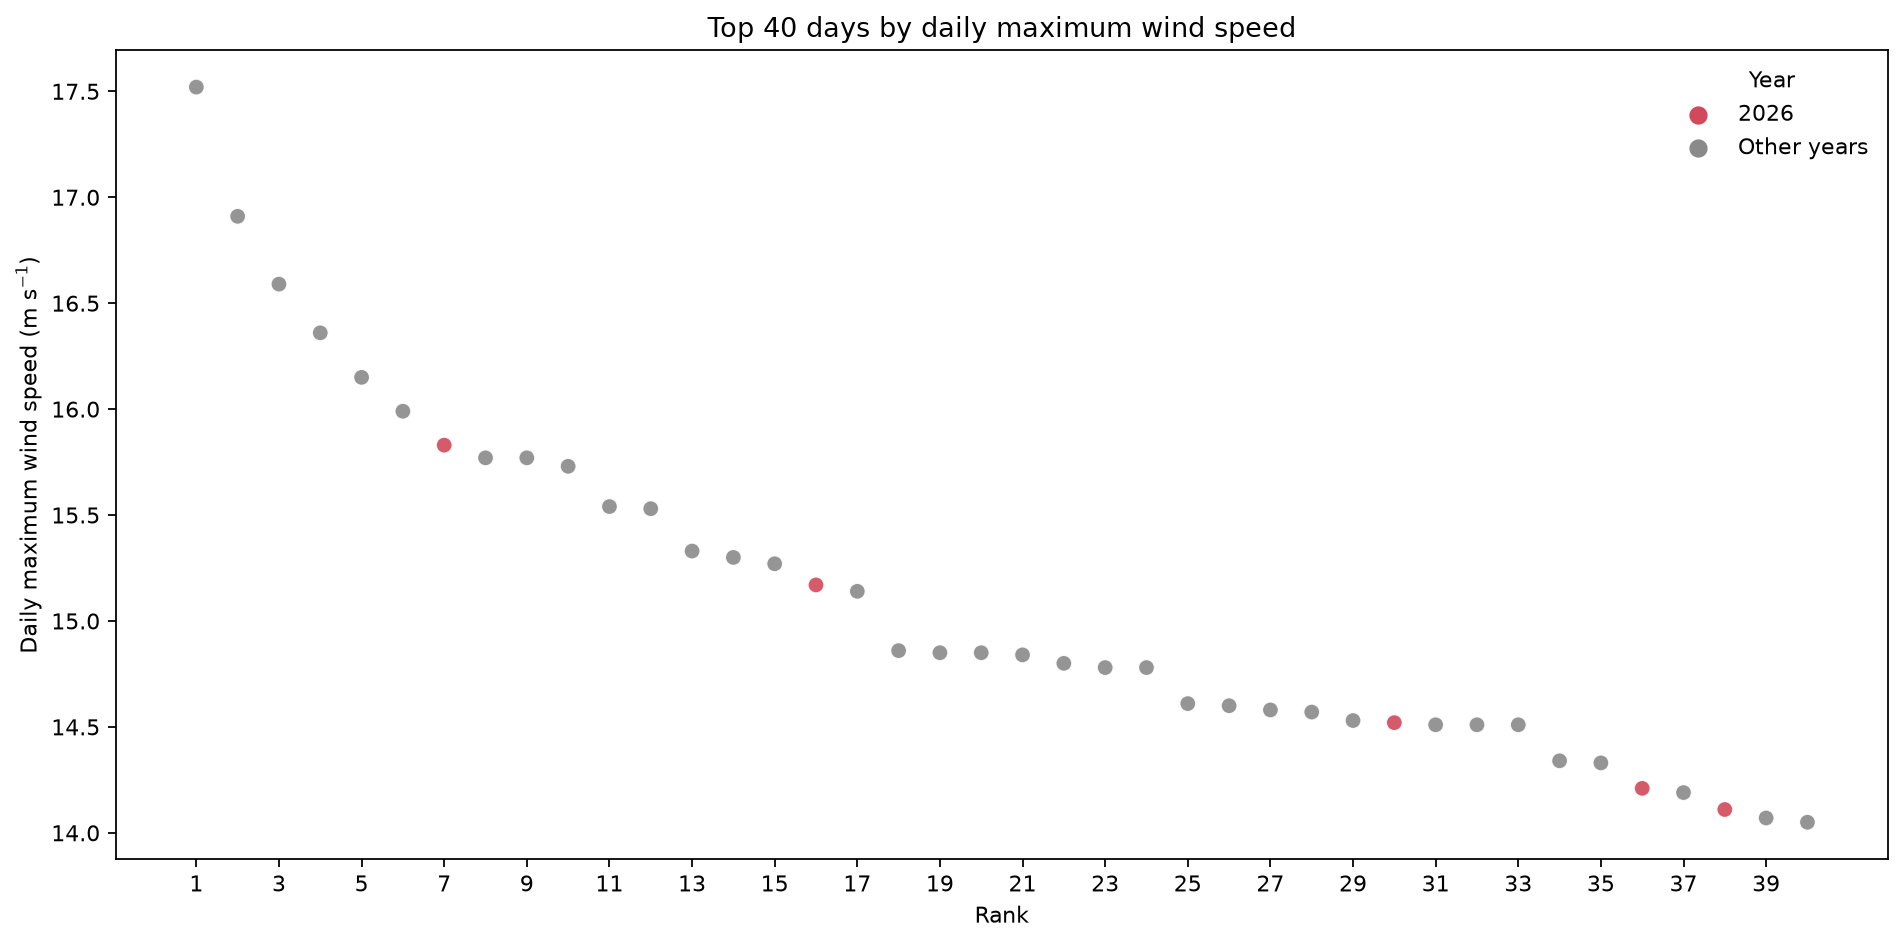

Mean-wind points plotted: 40
Maximum-wind points plotted: 40
2026 mean-wind points: 3
2026 maximum-wind points: 5


In [11]:
# Use the existing top-40 tables and highlight 2026 separately.
mean_dotplot_data = top_40_mean.copy()
mean_dotplot_data["rank"] = np.arange(1, len(mean_dotplot_data) + 1)
mean_dotplot_colors = np.where(mean_dotplot_data["year"] == 2026, "#d1495b", "#8a8a8a")

figure, axis = plt.subplots(figsize=(12, 6), dpi=160)
axis.scatter(mean_dotplot_data["rank"], mean_dotplot_data["daily_mean"], c=mean_dotplot_colors, s=52, alpha=0.9, edgecolors="white", linewidths=0.6)
axis.scatter([], [], color="#d1495b", s=52, label="2026")
axis.scatter([], [], color="#8a8a8a", s=52, label="Other years")
axis.set_title("Top 40 days by daily mean wind speed")
axis.set_xlabel("Rank")
axis.set_ylabel("Daily mean wind speed (m s$^{-1}$)")
axis.set_xticks(range(1, len(mean_dotplot_data) + 1, 2))
axis.legend(frameon=False, title="Year")
figure.tight_layout()
MEAN_WIND_DOTPLOT_PNG = GRAPHS_DIR / "geneva_top40_daily_mean_wind_speed_dotplot.png"
figure.savefig(MEAN_WIND_DOTPLOT_PNG, bbox_inches="tight")
plt.show()

max_dotplot_data = top_40_max.copy()
max_dotplot_data["rank"] = np.arange(1, len(max_dotplot_data) + 1)
max_dotplot_colors = np.where(max_dotplot_data["year"] == 2026, "#d1495b", "#8a8a8a")

figure, axis = plt.subplots(figsize=(12, 6), dpi=160)
axis.scatter(max_dotplot_data["rank"], max_dotplot_data["daily_max"], c=max_dotplot_colors, s=52, alpha=0.9, edgecolors="white", linewidths=0.6)
axis.scatter([], [], color="#d1495b", s=52, label="2026")
axis.scatter([], [], color="#8a8a8a", s=52, label="Other years")
axis.set_title("Top 40 days by daily maximum wind speed")
axis.set_xlabel("Rank")
axis.set_ylabel("Daily maximum wind speed (m s$^{-1}$)")
axis.set_xticks(range(1, len(max_dotplot_data) + 1, 2))
axis.legend(frameon=False, title="Year")
figure.tight_layout()
MAX_WIND_DOTPLOT_PNG = GRAPHS_DIR / "geneva_top40_daily_max_wind_speed_dotplot.png"
figure.savefig(MAX_WIND_DOTPLOT_PNG, bbox_inches="tight")
plt.show()

print(f"Mean-wind points plotted: {len(mean_dotplot_data):,}")
print(f"Maximum-wind points plotted: {len(max_dotplot_data):,}")
print(f"2026 mean-wind points: {(mean_dotplot_data['year'] == 2026).sum():,}")
print(f"2026 maximum-wind points: {(max_dotplot_data['year'] == 2026).sum():,}")